Instrument Classification and Robustness Analysis Topic Research

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import librosa
import numpy as np  

In [3]:
#Data Path
data_home = "./mirdata/IRMAS-TrainingData"
y_audio_path = "./mirdata/IRMAS-TrainingData/cel/[cel][cla]0001__1.wav"

#load and test data
y, sr = librosa.load(y_audio_path,sr=44100)
#Audio sample in 44.1khz
print(y.shape, sr)



c:\Users\leo89\anaconda3\envs\mir\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(132299,) 44100


C:\Users\leo89\AppData\Local\Temp\ipykernel_25660\3082606560.py:5: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  img = librosa.display.specshow(Y,y_axis='log', x_axis='time', ax=ax)


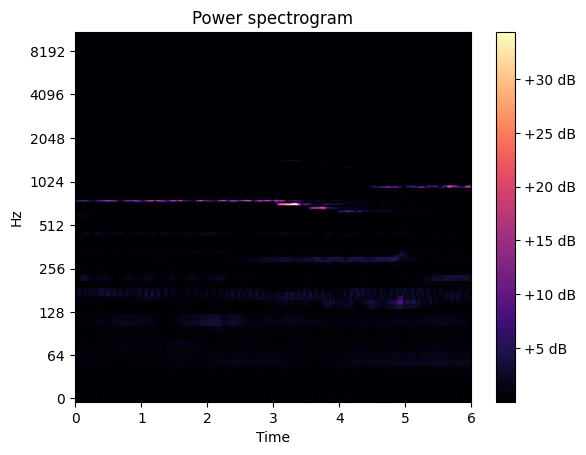

In [3]:
import matplotlib.pyplot as plt 
#audio spectrogram
Y = librosa.stft(y)
fig, ax = plt.subplots()
img = librosa.display.specshow(Y,y_axis='log', x_axis='time', ax=ax)
ax.set_title('Power spectrogram')
fig.colorbar(img, ax=ax, format="%+2.0f dB")




In [16]:
from dataset_preprocessing import create_dataset_csv
class_label = {'cel':0, 'pia':1, 'sax':2, 'flu':3, 'vio':4}

#load all data
df = create_dataset_csv(data_home)
#filter data by class label, only 5 classes are used in this project
df_filtered = df[df['label'].isin(class_label.keys())].copy()
df_filtered['label_id'] = df_filtered['label'].map(class_label)

print(df_filtered['label'].value_counts())

label
pia    721
sax    626
vio    580
flu    451
cel    388
Name: count, dtype: int64


In [5]:
import pandas as pd

save_path = "./mirdata/IRMAS-TrainingData/df_filtered_5_classes.csv"
df_filtered.to_csv(save_path, index=False, encoding='utf-8')

print("Filtered dataset saved to:", save_path)

Filtered dataset saved to: ./mirdata/IRMAS-TrainingData/df_filtered_5_classes.csv


Load CSV, starting from here.

In [3]:
import pandas as pd

save_path = "./mirdata/IRMAS-TrainingData/df_filtered_5_classes.csv"
#read the saved csv file to verify
df_dataset = pd.read_csv(save_path)
print(df_dataset.head())


                                           file_path label  label_id
0  ./mirdata/IRMAS-TrainingData\cel\008__[cel][no...   cel         0
1  ./mirdata/IRMAS-TrainingData\cel\008__[cel][no...   cel         0
2  ./mirdata/IRMAS-TrainingData\cel\008__[cel][no...   cel         0
3  ./mirdata/IRMAS-TrainingData\cel\012__[cel][no...   cel         0
4  ./mirdata/IRMAS-TrainingData\cel\012__[cel][no...   cel         0


In [4]:
from sklearn.utils import shuffle

#shuffle the dataset
train_df = shuffle(df_dataset)

print("Training set size:", len(train_df))
print("Train set",train_df.head())

Training set size: 2766
Train set                                               file_path label  label_id
2504  ./mirdata/IRMAS-TrainingData\vio\[vio][jaz_blu...   vio         4
1423  ./mirdata/IRMAS-TrainingData\pia\[pia][jaz_blu...   pia         1
2112  ./mirdata/IRMAS-TrainingData\sax\[sax][pop_roc...   sax         2
688   ./mirdata/IRMAS-TrainingData\flu\[flu][jaz_blu...   flu         3
2319  ./mirdata/IRMAS-TrainingData\vio\133__[vio][no...   vio         4


Text(0.5, 1.0, 'Distribution of Class Labels in Training Set')

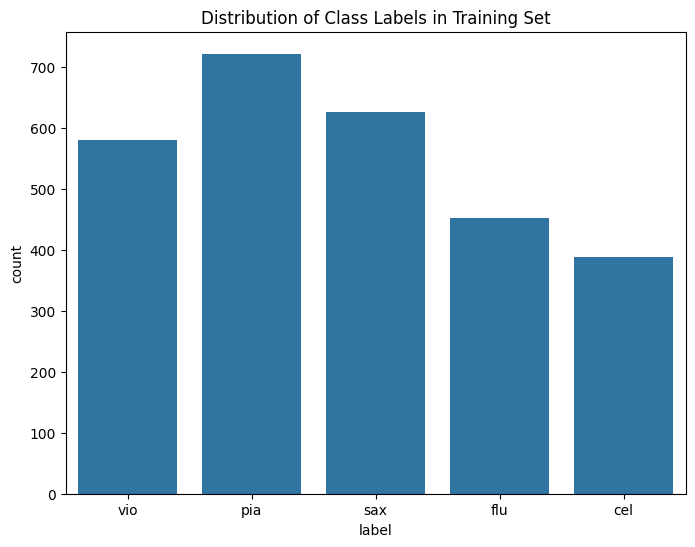

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt 

# Visualize the distribution of class labels in the training set
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=train_df)
plt.title('Distribution of Class Labels in Training Set')

In [6]:
y_train = train_df['label_id'].values
#y_test = test_df['label_id'].values
train_set = train_df['file_path'].values
#test_set = test_df['file_path'].values

#spilt to a smaller training set, set 200
#y_train = y_train[:200]
#train_set = train_set[:200]

#check whether the size match 
assert len(y_train) == len(train_set), "Trainset not aligned"
#assert len(y_test) == len(test_set), "Testset not aligned"

In [10]:
from dataset_preprocessing import convert_audio_to_mel_spectrogram

#convert audio to spectrogram for training
x_train = np.array(convert_audio_to_mel_spectrogram(train_set))
#x_test = np.array(convert_audio_to_mel_spectrogram(test_set))
print(x_train.shape)
#print(x_test.shape)


(2766, 128, 259)


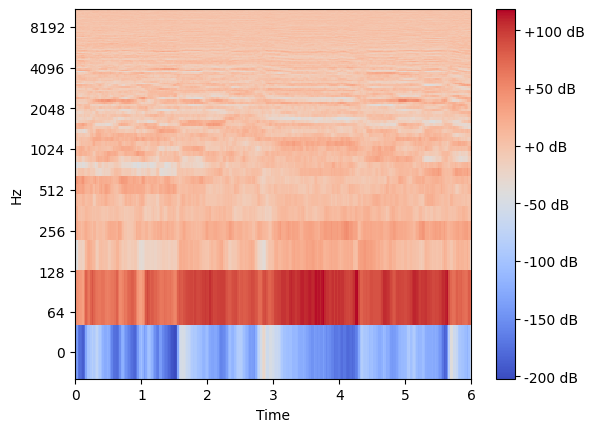

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
img = librosa.display.specshow(x_train[0],y_axis='log', x_axis='time', ax=ax)
fig.colorbar(img, ax=ax, format="%+2.0f dB")

Prepare TestSet Dataset(real-life instrument)

In [17]:
testset_path = "./mirdata/Freesound-TestData"

from dataset_preprocessing import create_dataset_csv
class_label = {'cel':0, 'pia':1, 'sax':2, 'flu':3, 'vio':4}

#load all data
df = create_dataset_csv(testset_path)
#filter data by class label, only 5 classes are used in this project
df_testset_filtered = df[df['label'].isin(class_label.keys())].copy()
df_testset_filtered['label_id'] = df_testset_filtered['label'].map(class_label)

print(df_testset_filtered['label'].value_counts())


label
cel    20
flu    20
pia    20
sax    20
vio    20
Name: count, dtype: int64


Dataset Re-formating

In [30]:
from dataset_preprocessing import audio_format_conversion, audio_trim

ins_folder = "./mirdata/Freesound-TestData/sax"

#audio_format_conversion(ins_folder)
audio_trim(ins_folder)

171198__vedas__sop-sax-solo-reverb.wav
./mirdata/Freesound-TestData/sax\171198__vedas__sop-sax-solo-reverb.wav
Trimmed and saved:  ./mirdata/Freesound-TestData/sax\171198__vedas__sop-sax-solo-reverb.wav
187099__simondsouza__alto-sax-90bpm-cm-4-solo.wav
./mirdata/Freesound-TestData/sax\187099__simondsouza__alto-sax-90bpm-cm-4-solo.wav
Trimmed and saved:  ./mirdata/Freesound-TestData/sax\187099__simondsouza__alto-sax-90bpm-cm-4-solo.wav
187142__timbre__kenny-g-style-remix-of-187099__simondsouza__alto-sax-90bpm-cm-4-solo (1).wav
./mirdata/Freesound-TestData/sax\187142__timbre__kenny-g-style-remix-of-187099__simondsouza__alto-sax-90bpm-cm-4-solo (1).wav
Trimmed and saved:  ./mirdata/Freesound-TestData/sax\187142__timbre__kenny-g-style-remix-of-187099__simondsouza__alto-sax-90bpm-cm-4-solo (1).wav
328931__rgrocc__sax-phrase-t5.wav
./mirdata/Freesound-TestData/sax\328931__rgrocc__sax-phrase-t5.wav
Trimmed and saved:  ./mirdata/Freesound-TestData/sax\328931__rgrocc__sax-phrase-t5.wav
348174__

In [18]:
import pandas as pd

save_path = "./mirdata/Freesound-TestData/df_filtered_5_classes.csv"
df_testset_filtered.to_csv(save_path, index=False, encoding='utf-8')

print("Filtered dataset saved to:", save_path)

Filtered dataset saved to: ./mirdata/Freesound-TestData/df_filtered_5_classes.csv


Load Test Set

In [14]:
import pandas as pd

save_path = "./mirdata/Freesound-TestData/df_filtered_5_classes.csv"
#read the saved csv file to verify
df_testset_filtered = pd.read_csv(save_path)
print(df_testset_filtered.head())

                                           file_path label  label_id
0  ./mirdata/Freesound-TestData\cel\124001__calpo...   cel         0
1  ./mirdata/Freesound-TestData\cel\124002__cello...   cel         0
2  ./mirdata/Freesound-TestData\cel\124003__cello...   cel         0
3  ./mirdata/Freesound-TestData\cel\124004__cello...   cel         0
4  ./mirdata/Freesound-TestData\cel\124005__cello...   cel         0


In [15]:
from sklearn.utils import shuffle

#shuffle the dataset
test_df = shuffle(df_testset_filtered)

print("Test set size:", len(test_df))
print("Test set",test_df.head())

Test set size: 100
Test set                                             file_path label  label_id
64  ./mirdata/Freesound-TestData\sax\348174__redaf...   sax         2
73  ./mirdata/Freesound-TestData\sax\745731__guaji...   sax         2
11  ./mirdata/Freesound-TestData\cel\124012__cello...   cel         0
94  ./mirdata/Freesound-TestData\vio\750642__grego...   vio         4
44  ./mirdata/Freesound-TestData\pia\251254__ekvel...   pia         1


SVM Data preprocessing below!

In [12]:
#reshape for svm, not for cnn
x_train_reshape = x_train.reshape((x_train.shape[0], 128*259))
#x_test_reshape = x_test.reshape((x_test.shape[0], 128*259))

In [13]:
from run_svm import train_svm
#run svm
clf = train_svm(x_train_reshape, y_train)

[LibSVM]

F1 and Accuracy Score Metric For SVM

In [35]:
#get test data
y_test = test_df['label_id'].values
x_test = test_df['file_path'].values

#convert audio to spectrogram for testing
x_test = np.array(convert_audio_to_mel_spectrogram(x_test))
x_test_reshape = x_test.reshape((x_test.shape[0], 128*259))

In [37]:
from run_svm import predict_svm
#predict the test set
y_predict = predict_svm(clf, x_test_reshape)
print(y_predict[0])
print(y_test[0])


2
2


In [38]:
from sklearn.metrics import f1_score, accuracy_score
print("f1 score for SVM:", format(f1_score(y_test, y_predict, average="macro")))
print("accuracy score for SVM:", format(accuracy_score(y_test, y_predict)))

f1 score for SVM: 0.5292869791888024
accuracy score for SVM: 0.54


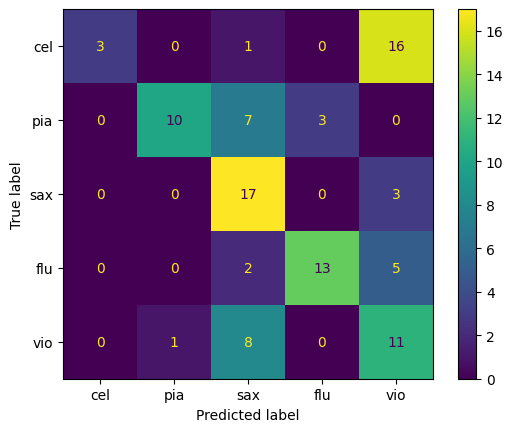

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

svm_cm = confusion_matrix(y_test, y_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=svm_cm,display_labels= ["cel", "pia", "sax", "flu", "vio"] )
disp.plot()

Dataset spilt for CNN

In [43]:
from dataset_preprocessing import normalize_split_data

x_train_cnn, y_train_cnn, x_val_cnn, y_val_cnn = normalize_split_data(x_train, y_train, val_size=0.2)
print(x_train_cnn.shape)
print(y_train_cnn.shape)
print(x_val_cnn.shape)
print(y_val_cnn.shape)


(2213, 128, 259)
(2213,)
(553, 128, 259)
(553,)


In [91]:
from run_cnn import convolutional_model

input_shape = (128, 259, 1)
cnn_model = convolutional_model(input_shape=input_shape)
cnn_model.summary()


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 128, 259, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 128, 259, 8)    │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 128, 259, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 64, 129, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 64, 129, 8)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 129, 16)    │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64, 129, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 32, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 5)              │       163,845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,189 (645.27 KB)

 Trainable params: 165,141 (645.08 KB)

 Non-trainable params: 48 (192.00 B)

In [92]:
from tensorflow import keras

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
]

In [93]:
clf_cnn = cnn_model.fit(x_train_cnn, y_train_cnn, epochs=20, batch_size=32, validation_data=(x_val_cnn, y_val_cnn), callbacks=callbacks)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.4162 - loss: 4.8082 - val_accuracy: 0.3743 - val_loss: 1.5747 - learning_rate: 0.0010
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7067 - loss: 1.4644 - val_accuracy: 0.4557 - val_loss: 1.8151 - learning_rate: 0.0010
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8251 - loss: 0.7028 - val_accuracy: 0.5208 - val_loss: 1.6891 - learning_rate: 0.0010
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8644 - loss: 0.5201 - val_accuracy: 0.5443 - val_loss: 1.9433 - learning_rate: 0.0010
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9209 - loss: 0.2876 - val_accuracy: 0.5425 - val_loss: 1.9903 - learning_rate: 0.0010
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9426 - loss: 0.2239 - val_accuracy: 0.5588 - val_loss: 2.2567 - learning_rate: 0.0010
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9693 - loss: 0.0882 - val_acc

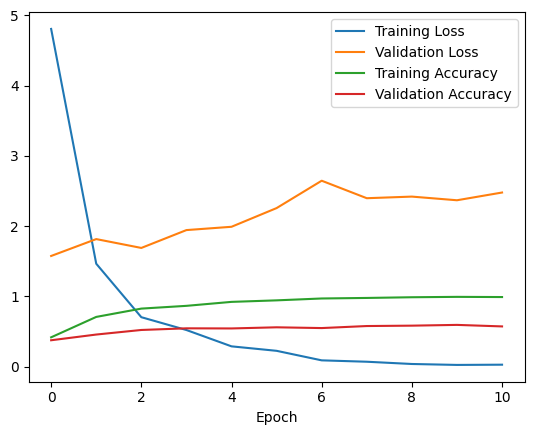

In [94]:
import matplotlib.pyplot as plt


plt.plot(clf_cnn.history['loss'], label='Training Loss')
plt.plot(clf_cnn.history['val_loss'], label='Validation Loss')
plt.plot(clf_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(clf_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
#plt.ylabel('Loss')
plt.legend()
plt.show()

In [95]:
from run_cnn import predict_cnn
y_predict_cnn = predict_cnn(cnn_model, x_test)
print(y_predict_cnn[0])
print(y_test[0])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
2
2


In [96]:
#save the trained cnn model
cnn_model.save("./checkpoints/cnn_model_4.keras")

In [97]:
from sklearn.metrics import f1_score, accuracy_score
print("f1 score for CNN:", format(f1_score(y_test, y_predict_cnn, average="macro")))
print("accuracy score for CNN:", format(accuracy_score(y_test, y_predict_cnn)))

f1 score for CNN: 0.06666666666666667
accuracy score for CNN: 0.2


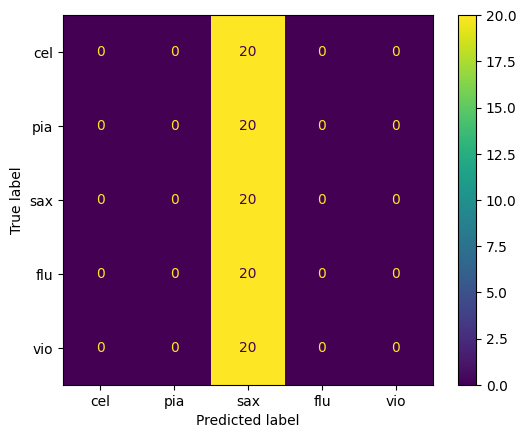

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cnn_cm = confusion_matrix(y_test, y_predict_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm,display_labels= ["cel", "pia", "sax", "flu", "vio"])
disp.plot()